# Filter out tracks based on criteria

In [1]:
import pandas as pd 
import numpy as np 
import sys
import napari
import zarr
import dask.array as da
import os
import matplotlib.pyplot as plt

pythonPackagePath = os.path.abspath(r'D:\LLSM-CME-ANALYSIS\Final\src')
sys.path.append(pythonPackagePath)

from filters import Track, create_tracks_from_dataframe, drop_short_tracks
from filters import drop_early_peak_tracks, drop_last_frame_peak_tracks, drop_tracks_below_intensity
from filters import plot_z_sum, allocate_membrane_regions, plot_z_sum_bd
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

Do not change the code in the cell below 

In [6]:
base_dir = r'\\10.158.28.194\ActiveNAS\Kenny\SiRActinData'
#base_dir = r'C:\Users\Kenny\akamatsu'
input_file_directory = '100nM_SiRactin_analysis/'

# # If a folder named 'datasets' doesn't exist in base_dir + input_file_directory, it will be created
# if not os.path.exists(os.path.join(base_dir, input_file_directory, 'datasets')):
#     os.makedirs(os.path.join(base_dir, input_file_directory, 'datasets'))

zarr_file_directory = '41OS_0-5min_analysis/zarr_file/all_channels_data'
zarr_full_path = os.path.join(base_dir, zarr_file_directory)

if import_trackability:
    input_directory = os.path.join(base_dir, input_file_directory_trackability) + 'datasets/track_df_cleaned_final_trackability.pkl'
else:
    input_directory = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'

# List which channel was used for detection and tracking
channel_detected = 3

output_directory = 'datasets'
output_file_name = 'filtered_tracks_final_with_filter.pkl'
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)

In [3]:
# # This assumes that your notebook is inside 'Jupyter Notebooks', which is at the same level as 'test_data'
# base_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), '..', 'movie_data')

# zarr_directory = 'zarr_file/all_channels_data'
# zarr_full_path = os.path.join(base_dir, zarr_directory)

# input_directory = 'datasets'
# input_file_name = 'track_df_cleaned_final_full.pkl'
# input_directory_full = os.path.join(base_dir,input_directory, input_file_name)

# output_directory = 'datasets'
# output_file_name = 'filtered_tracks_final.pkl'
# output_directory_full = os.path.join(base_dir,output_directory, output_file_name)

In [7]:
# open tracks and movie
track_df = pd.read_pickle(input_directory)
z2 = zarr.open(zarr_full_path, mode='r')

## Set filtering parameters below

In [8]:
# Drop tracks shorter than this length (in frames)
threshold_length = 3

# Drop tracks in which the peak intensity happens at or before this frame
peak_cutoff = 3

# set this to false if you don't want to classify by apical, lateral, basal
membrane_regions_exist = True

# set default channel names (optionally adjust)

channel1_name = 'channel 1'
channel2_name = 'channel 2'
channel3_name = 'channel 3'


In [9]:
# This is the minimum intensity value that a specific channel within a track must achieve to be considered positive for that channel.
threshold_intensity_channel_1 = 2500
threshold_intensity_channel_2 = 2500

In [10]:
# three channels
tracks = create_tracks_from_dataframe(df = track_df, intensities_col_name = ['c3_peak_mean', 'c2_peak_mean', 'c1_peak_mean'], 
track_id_col_name = 'track_id', frame_col_name = 'frame', coords = ['mu_x', 'mu_y', 'mu_z'])

# two channels
# tracks = create_tracks_from_dataframe(df = track_df, intensities_col_name = ['c2_peak_mean', 'c1_peak_mean'], 
# track_id_col_name = 'track_id', frame_col_name = 'frame', coords = ['mu_x', 'mu_y', 'mu_z'], adjusted_voxel_sum_col_name =['c2_voxel_sum_adjusted','c1_peak_mean'])

In [11]:
# Create DataFrame from Track instances
tracks_data = {
    'mu_x': [track.x for track in tracks],
    'mu_y': [track.y for track in tracks],
    'mu_z': [track.z for track in tracks],
    'trackability': [track.trackability for track in tracks],
    'track_id': [track.track_id.values[0] for track in tracks],
    'track_length': [track.track_length for track in tracks],
    'track_start': [track.track_start for track in tracks],
    'track_end': [track.track_end for track in tracks],
    'c3_peak': [track.peak_intensities[0] for track in tracks],
    'c2_peak': [track.peak_intensities[1] for track in tracks],
    'c1_peak': [track.peak_intensities[2] for track in tracks],
    'c3_peak_frame': [track.peak_intensity_frames[0] for track in tracks],
    'c2_peak_frame': [track.peak_intensity_frames[1] for track in tracks],
    'c1_peak_frame': [track.peak_intensity_frames[2] for track in tracks],
    'mean_displacement': [track.mean_displacement_track for track in tracks],
    'mean_z': [track.mean_z_value for track in tracks],
    'mean_z_displacement': [track.mean_z_displacement for track in tracks], 
    'max_radius_from_origin': [track.max_radius_from_origin for track in tracks], 
    'max_distance_between_two_points': [track.max_distance_between_two_points for track in tracks], 
    'c3_voxel_sum_adjusted': [track.adjusted_voxel_sum_c3 for track in tracks],
    'c2_voxel_sum_adjusted': [track.adjusted_voxel_sum_c2 for track in tracks],
    'c1_voxel_sum_adjusted': [track.adjusted_voxel_sum_c1 for track in tracks],
    'c3_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[0] for track in tracks],
    'c2_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[1] for track in tracks],
    'c1_voxel_sum_adjusted_peak': [track.peak_adjusted_voxel_sum[2] for track in tracks],
    'c3_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[0] for track in tracks],
    'c2_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[1] for track in tracks],
    'c1_voxel_sum_adjusted_peak_frame': [track.peak_adjusted_voxel_sum_frame[2] for track in tracks],
    'max_z_movement': [track.max_z_movement for track in tracks],
    'max_y_movement': [track.max_y_movement for track in tracks],
    'max_x_movement': [track.max_x_movement for track in tracks],
}

tracks_df = pd.DataFrame(tracks_data)
tracks_df.to_pickle(prefilter_output_directory_full)

In [9]:
tracks_df.head()

,mu_x,mu_y,mu_z,trackability,track_id,track_length,track_start,track_end,c3_peak,c2_peak,...,C1_adjusted_voxel_sum,C3_adjusted_voxel_sum_peak,C2_adjusted_voxel_sum_peak,C1_adjusted_voxel_sum_peak,C3_adjusted_voxel_sum_peak_frame,C2_adjusted_voxel_sum_peak_frame,C1_adjusted_voxel_sum_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,3365 110 7294 110 7352 111 1136...,3365 936 7294 936 7352 936 1136...,3365 17 7294 19 7352 20 11362 ...,None,0,117,0,116,230.565714,211.548571,...,"[1051.5263157894733, -42.73684210526699, 552.8...",13993.078947,6390.078947,4259.227074,36,9,113,65,8,38
1,3348 109 7249 110 7304 112 1130...,3348 1443 7249 1443 7304 1443 1...,3348 18 7249 19 7304 19 11306 ...,None,1,106,0,105,380.880000,332.817143,...,"[1200.5263157894733, 774.0263157894733, 1330.0...",27756.631579,14146.947368,4622.421053,87,87,92,66,21,42
2,3 134 3374 134 7303 134 1130...,3 1170 3374 1170 7303 1170 1...,3 23 3374 24 7303 25 11305 ...,None,2,105,0,104,296.731429,233.411429,...,"[12.368421052626218, 1157.842105263153, -859.2...",21166.157895,6925.947368,2422.917031,61,33,97,64,13,22
3,3329 106 7229 106 7335 107 1530...,3329 126 7229 126 7335 126 1530...,3329 8 7229 10 7335 12 15309 ...,None,3,79,0,78,222.948571,295.874286,...,"[1.105263157893205, 652.3421052631566, -255.31...",13218.631579,14356.105263,17345.421053,38,68,71,58,17,21
4,140 107 7088 107 11264 108 1140...,140 1083 7088 1083 11264 1083 1...,140 15 7088 16 11264 17 11400 ...,None,4,78,0,77,336.337143,336.068571,...,"[-5.184210526320385, 498.3157894736796, 444.5,...",24933.342105,13483.052632,10224.210526,26,63,62,65,8,35


In [ ]:
all_sec = tracks_df[tracks_df['track_start'] <= 3]
all_sec = all_sec[all_sec['track_end'] == 119]
len(all_sec)

93

### Filtering Functions

In [17]:
def filter_pixel_spots(tracks, pixel_edge, x_max, y_max, z_max):
    '''
    Filters outs that are close to the pixel edges in any dimension at any point in the track.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    pixel_edge (int): Number of pixels from the edge to consider as "close"
    x_max (int): Maximum x dimension of the image
    y_max (int): Maximum y dimension of the image
    z_max (int): Maximum z dimension of the image

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that are not close to the edges
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    
    '''
    mask = pd.Series(True, index=tracks_df.index)
    for i in range(len(tracks)):
        test = any(np.array(tracks_df["mu_x"][i].tolist()) > pixel_edge) & any(np.array(tracks_df["mu_y"][i].tolist()) > pixel_edge) \
                & any(np.array(tracks_df["mu_z"][i].tolist()) > pixel_edge) & any(np.array(tracks_df["mu_x"][i].tolist()) < x_max - pixel_edge) \
                & any(np.array(tracks_df["mu_y"][i].tolist()) < y_max - pixel_edge) & any(np.array(tracks_df["mu_z"][i].tolist()) < z_max - pixel_edge)
        mask[i] = test
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

def filter_track_frames(tracks, filter_start = 0, filter_end = z2.shape[0]):
    '''
    Filters out tracks that start before filter_start or end after filter_end.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    filter_start (int): Frame number before which tracks will be filtered out
    filter_end (int): Frame number after which tracks will be filtered out
    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that start after filter_start and end before
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''

    mask = pd.Series(True, index=tracks.index)
    if filter_start is not None:
        mask &= tracks["track_start"] > filter_start
    if filter_end is not None:
        mask &= tracks["track_end"] < filter_end
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [18]:
def measure_rolling_linearity(track_df, track_id, channel='c3_voxel_sum_adjusted', window_size=4):
    """
    Measure the linearity across rolling windows of n datapoints for a track.
    
    Parameters:
    track_df (DataFrame): Full track dataframe
    track_id (int): Track ID to analyze
    channel (str): Channel column to analyze
    window_size (int): Size of rolling window (default: 4)
    
    Returns:
    dict: Contains arrays of slopes, r_squared values, and window info
    """
    mask = pd.Series(True, index=tracks_df.index)
    # Get track data
    track_data = track_df[track_df['track_id'] == track_id].copy()
    
    if len(track_data) < window_size:
        return {
            'slopes': [],
            'r_squared_values': [],
            'window_starts': [],
            'window_ends': [],
            'error': f'Track has only {len(track_data)} points, need at least {window_size}'
        }
    
    # Sort by frame to ensure correct order
    track_data = track_data.sort_values('frame')
    
    # Initialize lists to store results
    slopes = []
    r_squared_values = []
    window_starts = []
    window_ends = []
    
    # Calculate number of possible windows
    num_windows = len(track_data) - window_size + 1
    
    # Iterate through all possible windows
    for i in range(num_windows):
        # Get window data
        window_data = track_data.iloc[i:i+window_size]
        
        # Extract x (frame) and y (intensity) values
        x = window_data['frame'].values
        y = window_data[channel].values
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        r_squared = r_value ** 2
        
        # Store results
        slopes.append(slope)
        r_squared_values.append(r_squared)
        window_starts.append(x[0])
        window_ends.append(x[-1])
    
    return {
        'slopes': slopes,
        'r_squared_values': r_squared_values,
        'window_starts': window_starts,
        'window_ends': window_ends,
        'window_size': window_size,
        'num_windows': num_windows,
        'track_length': len(track_data)
    }

In [19]:
def filter_linearity(tracks_df,window_size=4, r2_threshold=0.75, two_slopes=False):
    '''
    Filters tracks based on linearity of intensity changes over time.

    Parameters:
    tracks_df (pd.DataFrame): DataFrame containing track information
    window_size (int): Size of rolling window for linearity measurement (default: 4)
    r2_threshold (float): R-squared threshold for linearity (default: 0.75)
    two_slopes (bool): If True, requires both positive and negative slopes with r2 above threshold and negative slope follows positive slope.
    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet linearity criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''
    mask = pd.Series(True, index=tracks_df.index)
    for i in tqdm(range(len(tracks_df)), desc="Processing tracks"):
        linearity_results = measure_rolling_linearity(track_df, tracks_df['track_id'][i], window_size=window_size)
        positive_found = False
        negative_found = False
        if two_slopes:
            for slope, r2_value in zip(linearity_results['slopes'], linearity_results['r_squared_values']):
                if slope > 0 and r2_value > r2_threshold:
                    positive_found = True
                elif slope < 0 and r2_value > r2_threshold and positive_found:
                    negative_found = True
            if positive_found and negative_found:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if 'error' in linearity_results or all(np.array(linearity_results['r_squared_values']) < r2_threshold):
                mask[i] = False
            else:
                mask[i] = True
    return tracks_df[mask].reset_index(drop=True), tracks_df[~mask].reset_index(drop=True)

In [20]:
def detect_bursts(t, n_sigma=1.5):
    N = len(t)
    global_std = np.std(t)
    mean_left = np.cumsum(t) / (np.arange(N) + 1)
    mean_right = np.cumsum(t[::-1])[::-1] / (np.arange(N)[::-1] + 1)

    burst_mask = (t > mean_left + 1.5*global_std) & (t > mean_right + 1.5*global_std) # returns 1 if its higher than both the left and right means , else 0
    return burst_mask.astype(int)

def moving_average(x, window_size=3):
    return np.convolve(x, np.ones(window_size)/window_size, mode='same')

def closest_distance_between_ones(arr1, arr2):
    """Given two binary arrays, find the smallest absolute time difference between any 1 in arr1 and any 1 in arr2.
    Return None if no 1's found in either."""
    idx1 = np.where(arr1 == 1)[0]
    idx2 = np.where(arr2 == 1)[0]

    if len(idx1) == 0 or len(idx2) == 0:
        return None

    # Compute all pairwise distances, take the minimum
    dists = np.abs(idx1[:, None] - idx2[None, :])
    return np.min(dists)

def filter_dynmin_bursts(tracks, dist_max=10):
    '''
    Filters tracks based on the proximity of bursts between AP2 and dynamin.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    dist_max (int): Maximum allowed distance between bursts in frames (default: 10)

    returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that have bursts within dist_max frames
        pd.DataFrame: DataFrame with tracks that were filtered out
    
    '''
    closest_distances = []
    for i in tqdm(range(len(tracks)), desc="Processing tracks for dynmin bursts"):
        ap2_track = np.array(tracks['c3_voxel_sum_adjusted'][i])
        dnm2_track = np.array(tracks['c2_voxel_sum_adjusted'][i])
        # Skip tracks with different lengths
        if len(ap2_track) != len(dnm2_track):
            closest_distances.append(-1) # Filling -1 as a placeholder for no tracks that are not considered
            continue

        ap2_bursts = detect_bursts(ap2_track)
        dnm2_bursts = detect_bursts(dnm2_track)

        dist = closest_distance_between_ones(ap2_bursts, dnm2_bursts)
        if dist is None:
            closest_distances.append(-1) # Filling -1 as a placeholder for no tracks that are not considered
        else:
            closest_distances.append(dist) # Closest distance between bursts (in frames)
    #print(len(np.array(closest_distances)) == len(tracks))
    mask = (np.array(closest_distances) > 0) # Keep only tracks with at least one burst in both channels
    if dist_max > 0:
        mask &= (np.array(closest_distances) <= dist_max)
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [21]:
def filter_ap2_peaks(tracks, peak=1, isGreaterPeak=True):
    '''
    Filters tracks based on the number of AP2 peaks detected.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    peak (int): Number of peaks to filter on (default: 1)
    isGreaterPeak (bool): If True, keeps tracks with at least 'peak' number of peaks; if False, keeps tracks with exactly 'peak' number of peaks (default: True)

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet peak criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    '''
    mask = pd.Series(True, index=tracks.index)
    for i in tqdm(range(len(tracks)), desc="Processing AP2 Peaks"):
        ap2_track = np.array(tracks['c3_voxel_sum_adjusted'][i])
        ap2_bursts = detect_bursts(ap2_track)
        if isGreaterPeak:
            if np.sum(ap2_bursts) >= peak:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if np.sum(ap2_bursts) == peak:
                mask[i] = True
            else:
                mask[i] = False
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

In [22]:
def filter_arp23_peaks(tracks, channel_voxel_sum, peak=1, isGreaterPeak=True):
    '''
    Filters tracks based on the number of ARP2/3 peaks detected.

    Parameters:
    tracks (pd.DataFrame): DataFrame containing track information
    peak (int): Number of peaks to filter on (default: 1)
    isGreaterPeak (bool): If True, keeps tracks with at least 'peak' number of peaks; if False, keeps tracks with exactly 'peak' number of peaks (default: True)

    Returns:
    A tuple containing:
        pd.DataFrame: Filtered DataFrame with tracks that meet peak criteria
        pd.DataFrame: DataFrame with tracks that were filtered out
    '''
    mask = pd.Series(True, index=tracks.index)
    for i in tqdm(range(len(tracks)), desc="Processing AP2 Peaks"):
        arp2_track = np.array(tracks[channel_voxel_sum][i])
        arp2_bursts = detect_bursts(arp2_track)
        if isGreaterPeak:
            if np.sum(arp2_bursts) >= peak:
                mask[i] = True
            else:
                mask[i] = False
        else:
            if np.sum(arp2_bursts) == peak:
                mask[i] = True
            else:
                mask[i] = False
    return tracks[mask].reset_index(drop=True), tracks[~mask].reset_index(drop=True)

### Combining all filtering functions into one function

In [23]:
def track_filtering(tracks, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=False,
                    doDynminBurstFilter=True, dist_max=10,
                    doLinearityFilter=True, window_size=4, r2_threshold=0.9, two_slopes=True):
    '''
    Combines all filtering functions to filter tracks based on multiple criteria.
    
    For the parameters, see the individual filtering functions:
    - filter_pixel_spots
    - filter_track_frames
    - filter_ap2_peaks
    - filter_dynmin_bursts
    - filter_linearity 
    '''
    
    filtered_tracks = tracks.copy(deep = True)
    dropped_tracks = pd.DataFrame()  # Initialize an empty DataFrame to store dropped tracks
    filtered_results = {}
    if doPixelFilter:
        filtered_tracks, dropped_pixel_tracks = filter_pixel_spots(filtered_tracks, pixel_edge, x_max, y_max, z_max)
        dropped_tracks = pd.concat([dropped_tracks, dropped_pixel_tracks], ignore_index=True)
        filtered_results['pixel_filter'] = dropped_pixel_tracks
        print(f"After Pixel Edge Filter: {len(filtered_tracks)} tracks remain, {len(dropped_pixel_tracks)} tracks dropped.")
    if doFrameFilter:
        filtered_tracks, dropped_frame_tracks = filter_track_frames(filtered_tracks, filter_start, filter_end)
        dropped_tracks = pd.concat([dropped_tracks, dropped_frame_tracks], ignore_index=True)
        filtered_results['frame_filter'] = dropped_frame_tracks
        print(f"After Frame Filter: {len(filtered_tracks)} tracks remain, {len(dropped_frame_tracks)} tracks dropped.")
    if doAP2PeakFilter:
        filtered_tracks, dropped_ap2_peak_tracks = filter_ap2_peaks(filtered_tracks, peak=ap2_peak, isGreaterPeak=isGreaterPeak)
        dropped_tracks = pd.concat([dropped_tracks, dropped_ap2_peak_tracks], ignore_index=True)
        filtered_results['ap2_peak'] = dropped_ap2_peak_tracks
        print(f"After AP2 Peak Filter: {len(filtered_tracks)} tracks remain, {len(dropped_ap2_peak_tracks)} tracks dropped.")
    if doDynminBurstFilter:
        filtered_tracks, dropped_burst_tracks = filter_dynmin_bursts(filtered_tracks, dist_max=dist_max)
        dropped_tracks = pd.concat([dropped_tracks, dropped_burst_tracks], ignore_index=True)
        filtered_results['dynmin_burst'] = dropped_burst_tracks
        print(f"After Dynmin Burst Filter: {len(filtered_tracks)} tracks remain, {len(dropped_burst_tracks)} tracks dropped.")
    if doLinearityFilter:
        filtered_tracks, dropped_linearity_tracks = filter_linearity(filtered_tracks, window_size=window_size, r2_threshold=r2_threshold, two_slopes=two_slopes)
        dropped_tracks = pd.concat([dropped_tracks, dropped_linearity_tracks], ignore_index=True)
        filtered_results['linearity_filter'] = dropped_linearity_tracks
        print(f"After Linearity Filter: {len(filtered_tracks)} tracks remain, {len(dropped_linearity_tracks)} tracks dropped.")
    filtered_results['result'] = filtered_tracks
    print(f"Final number of tracks after all filters:, {len(filtered_tracks)} and total tracks dropped: {len(dropped_tracks)}")
    return filtered_results

In [24]:
def orderFilters(tracks, doPixelFilter=True, pixel_order=0, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, frame_order=1, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_order=2, ap2_peak=1, isGreaterPeak=False,
                    doDynminBurstFilter=True, dynmin_order=3, dist_max=10,
                    doLinearityFilter=True, linearity_order=4, window_size=4, r2_threshold=0.9, two_slopes=True):
    '''
    Combines all filtering functions to filter tracks based on multiple criteria.
    
    For the parameters, see the individual filtering functions:
    - filter_pixel_spots
    - filter_track_frames
    - filter_ap2_peaks
    - filter_dynmin_bursts
    - filter_linearity 
    The order of applying the filters can be specified using the *_order parameters. Lower numbers indicate higher priority.
    '''
    # Setting up list of filters to sort and apply in order
    filters = []
    if doPixelFilter:
        filters.append((pixel_order, filter_pixel_spots, (pixel_edge, x_max, y_max, z_max)))
    if doFrameFilter:
        filters.append((frame_order, filter_track_frames, (filter_start, filter_end)))
    if doAP2PeakFilter:
        filters.append((ap2_order, filter_ap2_peaks, (ap2_peak, isGreaterPeak)))
    if doDynminBurstFilter:
        filters.append((dynmin_order, filter_dynmin_bursts, (dist_max,)))
    if doLinearityFilter:
        filters.append((linearity_order, filter_linearity, (window_size, r2_threshold, two_slopes)))
    
    filtered_tracks = tracks.copy(deep = True)
    dropped_tracks = pd.DataFrame()  # Initialize an empty DataFrame to store dropped tracks
    filtered_results = {}
    # Sort filters based on the specified order
    filters.sort(key=lambda x: x[0])
    # Apply filters in the specified order
    for i, func, args in filters:
        print(f"Filter step {i}, Applying {func.__name__}...")
        filtered_tracks, dropped = func(filtered_tracks, *args)
        dropped_tracks = pd.concat([dropped_tracks, dropped], ignore_index=True)
        filtered_results[func.__name__.replace("filter_","") + "_dropped"] = dropped
        filtered_results[func.__name__.replace("filter_","") + "_result"] = filtered_tracks
        print(f"After {func.__name__}: {len(filtered_tracks)} tracks remain, {len(dropped)} tracks dropped.")
    filtered_results['all_filtered_result'] = filtered_tracks
    filtered_results['all_dropped'] = dropped_tracks
    print(f"Final number of tracks after all filters:, {len(filtered_tracks)} and total tracks dropped: {len(dropped_tracks)}")
    return filtered_results

### New Filtering Testing

In [ ]:
# testing, testing_drop = track_filtering(tracks_df, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
#                     doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
#                     doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=False,
#                     doDynminBurstFilter=True, dist_max=10,
#                     doLinearityFilter=False, window_size=4, r2_threshold=0.9, two_slopes=True)
# tracks_df = testing

testing = track_filtering(tracks_df, doPixelFilter=True, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=True, filter_start=0, filter_end=z2.shape[0],
                    doAP2PeakFilter=True, ap2_peak=1, isGreaterPeak=False,
                    doDynminBurstFilter=True, dist_max=10,
                    doLinearityFilter=False, window_size=4, r2_threshold=0.9, two_slopes=True)

NameError: name 'track_filtering' is not defined

In [25]:
testing = orderFilters(tracks_df, doPixelFilter=True, pixel_order=0, pixel_edge=5, x_max=z2.shape[4], y_max=z2.shape[3], z_max=z2.shape[2],
                    doFrameFilter=False, frame_order=1, filter_start=0, filter_end=None, # z2.shape[0] - 1
                    doAP2PeakFilter=True, ap2_order=2, ap2_peak=1, isGreaterPeak=True,
                    doDynminBurstFilter=False, dynmin_order=3, dist_max=10,
                    doLinearityFilter=False, linearity_order=4, window_size=4, r2_threshold=0.9, two_slopes=True)

Filter step 0, Applying filter_pixel_spots...
After filter_pixel_spots: 46338 tracks remain, 106 tracks dropped.
Filter step 2, Applying filter_ap2_peaks...


Processing AP2 Peaks:   0%|          | 0/46338 [00:00<?, ?it/s]

After filter_ap2_peaks: 6307 tracks remain, 40031 tracks dropped.
Final number of tracks after all filters:, 6307 and total tracks dropped: 40137


In [18]:
testing['linearity_dropped']

KeyError: 'linearity_dropped'

In [26]:
tracks_df = testing['all_filtered_result']

In [92]:
testing = tracks_df[tracks_df["track_end"] >= z2.shape[0]-1]

testing

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,26 40.0 5486 40.0 5497 40.0 1...,26 70.0 5486 70.0 5497 70.0 1...,26 10.0 5486 10.0 5497 9.0 1...,0,120,0,119,252.228571,252.228571,136.194286,...,"[558.5789473684199, 83.44736842104976, 870.526...",13009.078947,13009.078947,1672.157895,103,103,119,6.0,2.0,2.0
1,2539 46.0 5485 45.0 5498 46.0 1...,2539 253.0 5485 252.0 5498 253....,2539 9.0 5485 11.0 5498 10.0 1...,1,120,0,119,232.074286,232.074286,152.822857,...,"[-139.4210526315801, -337.52631578947694, 54.8...",9557.657895,9557.657895,1335.131579,71,71,59,6.0,2.0,2.0
2,94 64.0 3184 65.0 7953 64.0 9...,94 200.0 3184 200.0 7953 199....,94 12.0 3184 10.0 7953 11.0 9...,2,120,0,119,187.485714,187.485714,170.057143,...,"[723.6052631578932, -65.63157894737014, 1494.2...",7417.105263,7417.105263,3704.815789,10,10,53,7.0,3.0,3.0
3,207 98.0 4269 98.0 6845 98.0 9...,207 708.0 4269 708.0 6845 708....,207 11.0 4269 10.0 6845 11.0 9...,3,120,0,119,267.571429,267.571429,148.108571,...,"[625.7368421052597, 721.2631578947367, 488.552...",14185.000000,14185.000000,1673.815789,105,105,107,6.0,2.0,2.0
4,335 105.0 4940 104.0 6117 105....,335 797.0 4940 797.0 6117 797....,335 11.0 4940 11.0 6117 11.0 1...,4,120,0,119,316.194286,316.194286,147.971429,...,"[690.78947368421, 814.3947368421032, 570.78947...",16496.500000,16496.500000,1629.078947,117,117,114,6.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46344,"409106 213.0 412545 214.0 Name: mu_x, dt...","409106 618.0 412545 619.0 Name: mu_y, dt...","409106 111.0 412545 109.0 Name: mu_z, dt...",46344,2,118,119,120.217143,120.217143,121.706667,...,"[326.7253886010367, -96.07894736842354]",1466.947368,1466.947368,326.725389,119,119,118,2.0,1.0,1.0
46345,"409107 210.0 415557 210.0 Name: mu_x, dt...","409107 915.0 415557 915.0 Name: mu_y, dt...","409107 107.0 415557 108.0 Name: mu_z, dt...",46345,2,118,119,132.908571,132.908571,114.697143,...,"[568.7105263157864, -357.5263157894733]",3322.815789,3322.815789,568.710526,118,118,118,1.0,0.0,0.0
46346,"409100 267.0 412540 268.0 Name: mu_x, dt...","409100 760.0 412540 760.0 Name: mu_y, dt...","409100 111.0 412540 109.0 Name: mu_z, dt...",46346,2,118,119,125.046667,125.046667,136.440000,...,"[526.7409326424859, 930.28947368421]",1413.105263,1413.105263,930.289474,119,119,119,2.0,0.0,1.0
46347,"409099 237.0 412539 237.0 Name: mu_x, dt...","409099 521.0 412539 521.0 Name: mu_y, dt...","409099 111.0 412539 111.0 Name: mu_z, dt...",46347,2,118,119,115.846667,115.846667,113.413333,...,"[5.5077720207264065, -0.9533678756488371]",761.974093,761.974093,5.507772,119,119,118,0.0,0.0,0.0


#### Intensities of dropped tracks

In [42]:
def test_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, track_id_col_name: str, 
                       frame_col_name: str, intensity_to_plot: list, channels_to_plot: int, legend_values: list = ['Channel 3', 'Channel 2', 'Channel 1'], 
                       line_colors: list = ['red', 'green', 'blue'], graph_title = 'Intensity', normalized: bool = False):
    
    '''
    
    The function takes in the list of track ids assigned to a cohort and aligns them with respect to their 
    peak values to a specific index. The index depends on bufferZero. Whatever the value of bufferZero is the
    peaks will be aligned with that value. 
    
    Parameters:
    1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
    1. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
    4. intensity_to_plot, type(list), the name of the columns to be used for plotting intensity. Note that the first value
    in this list should be for the primary channel, second value for the secondary channel and so on. 
    Default Value: ['amplitude', 'c2_peak']
    5. track_id_col_name: type(str), the column name which contains the frame number. Default value: 'track_id'
    6. legend_values: type(list), labels for the legend. Must be in line with intensity_to_plot list. The channel that is first in intensity_to_plot
    must also appear first in legend labels. 
    7. line_colors: type(list), colors for the intensity_to_plot lines. line_colors[0] will be the color for intensity_to_plot[0] and so on. 
    8. normalized: type(bool), if the intensity values are normalized. Default value: False

    Output: 
    1. Returns the array of primary channel tracks aligned with respect to secondary channel peaks
    2. Returns the array of secondary channel tracks where tracks are aligned with all peaks of tracks being on 
    the same index. (the index is determined by bufferZero)
    
    '''


    if channels_to_plot == 3 and len(intensity_to_plot) != 3: 
        raise ValueError('length of intensity_to_plot must equal channels_to_plot')
        
    num_rows = 1
    num_cols = 5
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(17.5, 6))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else np.array([axes])
    handles = []
    labels = []

    for i, track_id in enumerate(tracks_to_plot):
        # Filter DataFrame for the selected track_id
        track_data = dataframe[dataframe[track_id_col_name] == track_id].copy(deep = True)

        #length = filtered_df[filtered_df['track_id'] == track_id]['track_length'].values
        length = track_data.shape[0]

        lines = []
        for j in range(channels_to_plot):
            min_val = track_data[intensity_to_plot[j]].min()
            track_data[intensity_to_plot[j]] -= min_val
            max_val = track_data[intensity_to_plot[j]].max()          

            # normalize by max_intensity
            if normalized:  
                track_data[intensity_to_plot[j]] /= max_val
            line, = axes[i].plot(track_data[frame_col_name], track_data[intensity_to_plot[j]], label=intensity_to_plot[j], color=line_colors[j])
            lines.append(line)

        # if channels_to_plot == 2:
        #     min0 = track_data[intensity_to_plot[0]].min()
        #     min1 = track_data[intensity_to_plot[1]].min()
        #     track_data[intensity_to_plot[0]] = track_data[intensity_to_plot[0]] - min0
        #     track_data[intensity_to_plot[1]] = track_data[intensity_to_plot[1]] - min1
        #     line1, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[0]], label=intensity_to_plot[0], color = line_colors[0])
        #     line2, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[1]], label=intensity_to_plot[1], color = line_colors[1])
        # else: 
        #     min0 = track_data[intensity_to_plot[0]].min()
        #     min1 = track_data[intensity_to_plot[1]].min()
        #     min2 = track_data[intensity_to_plot[2]].min()
        #     track_data[intensity_to_plot[0]] = track_data[intensity_to_plot[0]] - min0
        #     track_data[intensity_to_plot[1]] = track_data[intensity_to_plot[1]] - min1
        #     track_data[intensity_to_plot[2]] = track_data[intensity_to_plot[2]] - min2
        #     line1, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[0]], label=intensity_to_plot[0], color = line_colors[0])
        #     line2, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[1]], label=intensity_to_plot[1],  color = line_colors[1])
        #     line3, = axes[row, col].plot(track_data[frame_col_name], track_data[intensity_to_plot[2]], label=intensity_to_plot[2], color = line_colors[2])
        axes[i].set_title(f'Track {track_id}, length {length}')
        axes[i].set_xlabel('Frame')
        axes[i].set_ylabel('Intensity')
        #axes[row, col].legend()

    fig.suptitle(f'{graph_title} over time', fontsize = 16, fontweight = 'bold')

    for i in range(channels_to_plot):
        handles.append(lines[i])
        labels.append(legend_values[i])
    # if (channels_to_plot == 2):
    #     # Set a single legend for all subplots
    #     handles.extend([line1, line2])
    #     labels.extend([legend_values[0], legend_values[1]])
    # else: 
    #     # Set a single legend for all subplots
    #     handles.extend([line1, line2, line3])
    #     labels.extend([legend_values[0], legend_values[1], legend_values[2]])
        
    # Set a single legend for all subplots
    fig.legend(handles, labels, loc='upper right', ncol=channels_to_plot, fontsize=18)
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.8, hspace=0.7)
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

In [56]:
value_to_plot = 'voxel_sum_adjusted'

# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = testing, desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 5)

test_intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

KeyError: 'track_length'

In [53]:
z_max = z2.shape[2]
y_max = z2.shape[3]
x_max = z2.shape[4]
print("x_max:", x_max, "y_max:", y_max, "z_max:", z_max)

x_max: 303 y_max: 2048 z_max: 114


In [21]:
tracks_df.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,c1_voxel_sum_adjusted,c3_voxel_sum_adjusted_peak,c2_voxel_sum_adjusted_peak,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement
0,2804 121.0 6031 122.0 6069 121....,2804 1289.0 6031 1289.0 6069 12...,2804 31.0 6031 31.0 6069 32.0 9...,1,120,0,119,262.817143,201.314286,132.108571,...,"[360.42105263157646, 291.36842105262986, 270.0...",14145.631579,6952.368421,782.052632,100,3,44,12.0,5.0,4.0
1,100 71.0 5893 71.0 6170 70.0 1...,100 876.0 5893 876.0 6170 876....,100 35.0 5893 35.0 6170 36.0 1...,2,120,0,119,214.897143,172.748571,123.291429,...,"[974.6756756756768, 416.9189189189201, 706.882...",11714.000000,3302.052632,974.675676,99,25,0,14.0,9.0,13.0
2,212 77.0 5780 77.0 6266 76.0 1...,212 86.0 5780 86.0 6266 86.0 1...,212 31.0 5780 32.0 6266 32.0 1...,3,120,0,119,333.068571,143.457143,116.022857,...,"[-154.60526315789684, -444.8157894736869, -124...",22986.368421,2269.473684,642.815789,87,90,94,6.0,5.0,6.0
3,343 161.0 5680 161.0 6361 161....,343 904.0 5680 905.0 6361 905....,343 40.0 5680 41.0 6361 41.0 1...,4,120,0,119,558.668571,267.314286,133.165714,...,"[642.5526315789466, 407.31578947368325, 364.18...",43096.605263,8977.076923,1584.147059,7,96,72,5.0,5.0,9.0
4,473 175.0 5567 176.0 6476 176....,473 1243.0 5567 1244.0 6476 12...,473 60.0 5567 60.0 6476 61.0 1...,5,120,0,119,221.514286,150.240000,127.874286,...,"[625.6842105263131, 591.1842105263131, 365.157...",11949.000000,1350.710526,1235.263158,87,87,6,7.0,7.0,7.0


Filter out tracks based on length and completeness

In [27]:
#dropping tracks of length 3 and below
length_filtered_tracks_df = drop_short_tracks(df = tracks_df, threshold = threshold_length)

# Drop incomplete tracks (starting at first frame or ending at last frame)
incomplete_tracks_df = tracks_df.loc[(tracks_df['track_start'] == 0) | (tracks_df['track_end'] == track_df['frame'].max())]
tracks_df_incomplete = tracks_df.drop(incomplete_tracks_df.index)
len(length_filtered_tracks_df)

6307

### Determining Valid Channel 3 tracks 
valid_c3_tracks will serve as baseline "clathrin positive" and valid tracks

In [28]:
### Dropping tracks with Channel 3 peak in the last frame
# valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'c3_peak_frame')
valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'c3_voxel_sum_adjusted_peak_frame')

### Dropping tracks with Channel 3 which have their peaks in the first three frames 
# valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c3_peak_frame',
#                                       cutoff = peak_cutoff)
valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c3_voxel_sum_adjusted_peak_frame',
                                      cutoff = peak_cutoff)


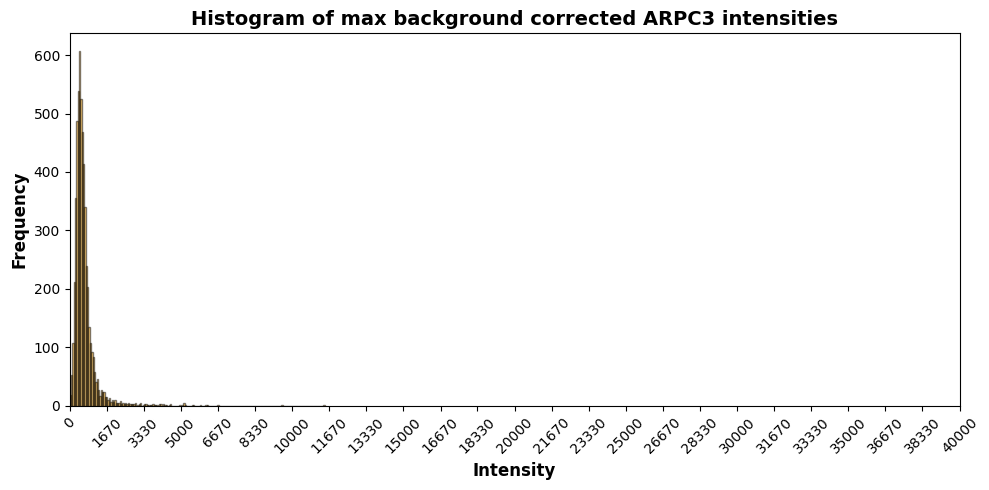

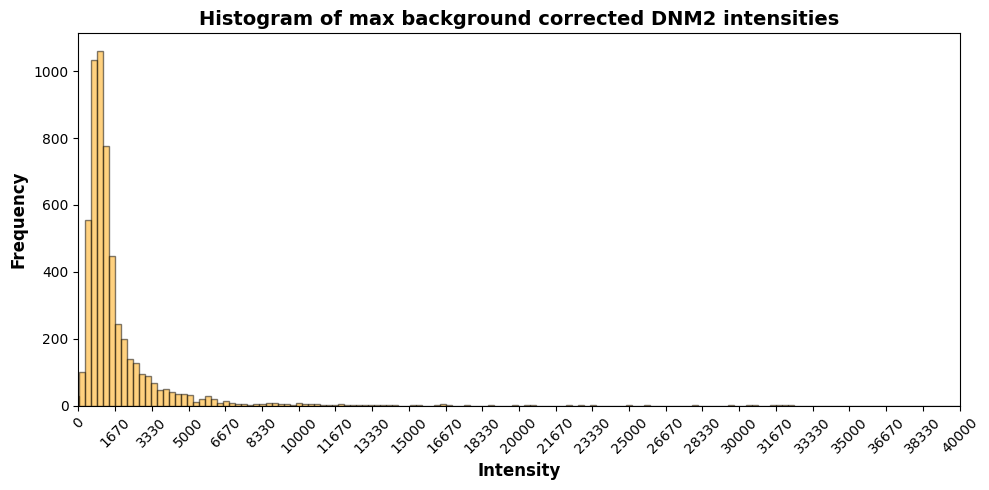

In [29]:
# Histogram of maximum background corrected ARPC3 intensity values, to determine cutoff for ARPC3-positive tracks
columns = ['c1_voxel_sum_adjusted_peak', 'c2_voxel_sum_adjusted_peak']
marker = ['ARPC3', 'DNM2']

# # Max AP2 intensity per track
# control_AP2 = tracks_channel_subset_control['C3_adjusted_voxel_sum'].reset_index(drop=True)

# max_control_AP2 = []
# for j in range(len(control_AP2)):
#     max_control_AP2.append(max(control_AP2[j]))  

for i in range(len(columns)):
    # Create a figure with 2 subplots side by side
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

    control =  valid_c3_tracks[columns[i]].reset_index(drop=True)
    

    max_control = []
    for j in range(len(control)):
        max_control.append(control[j])  # For every element in arpc3_control, get the max value



    # # Normalize to max AP2 intensity, optional
    # max_control = (np.array(max_control) / np.array(max_control_AP2)).tolist()
    


    # Generate 50 equally spaced bins between the min and max of max_arpc3_control and max_arpc3_OS
    # so I can plot the histograms of max_arpc3_control and max_arpc3_OS on the same plot
    # with the same binning
    bins = np.linspace(min(max_control), max(max_control), 200)


    # Plot histogram on the first subplot
    ax1.hist(max_control, bins=bins, color='orange', edgecolor='black', alpha=0.5, label='Control')

    # Calculate the data range
    # x_min = min(max_control)
    # x_max = max(max_control)
    x_min = 0
    x_max = 40000
    
    # Round minimum down and maximum up to nearest 10
    x_min_rounded = np.floor(x_min / 10) * 10
    x_max_rounded = np.ceil(x_max / 10) * 10
    
    # Create tick marks rounded to the nearest 10
    num_ticks =25  # Adjust this number for more or fewer ticks
    
    # Generate ticks rounded to the nearest 10
    x_ticks = np.linspace(x_min_rounded, x_max_rounded, num_ticks)
    x_ticks_rounded = np.round(x_ticks / 10) * 10  # Round to nearest 10
    
    ax1.set_xticks(x_ticks_rounded)
    ax1.set_xticklabels([f'{int(x)}' for x in x_ticks_rounded], rotation=45, fontsize=10)
    
    ax1.set_xlabel('Intensity', fontsize=12, weight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
    ax1.set_title('Histogram of max background corrected' + ' ' + marker[i] + ' ' +  'intensities', fontsize=14, weight='bold')

    # set x limit to 0 and 20000
    ax1.set_xlim(x_min_rounded, x_max_rounded)

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [ ]:
# valid_c3_tracks_filter = valid_c3_tracks[valid_c3_tracks['C1_adjusted_voxel_sum_peak'] > 4000]

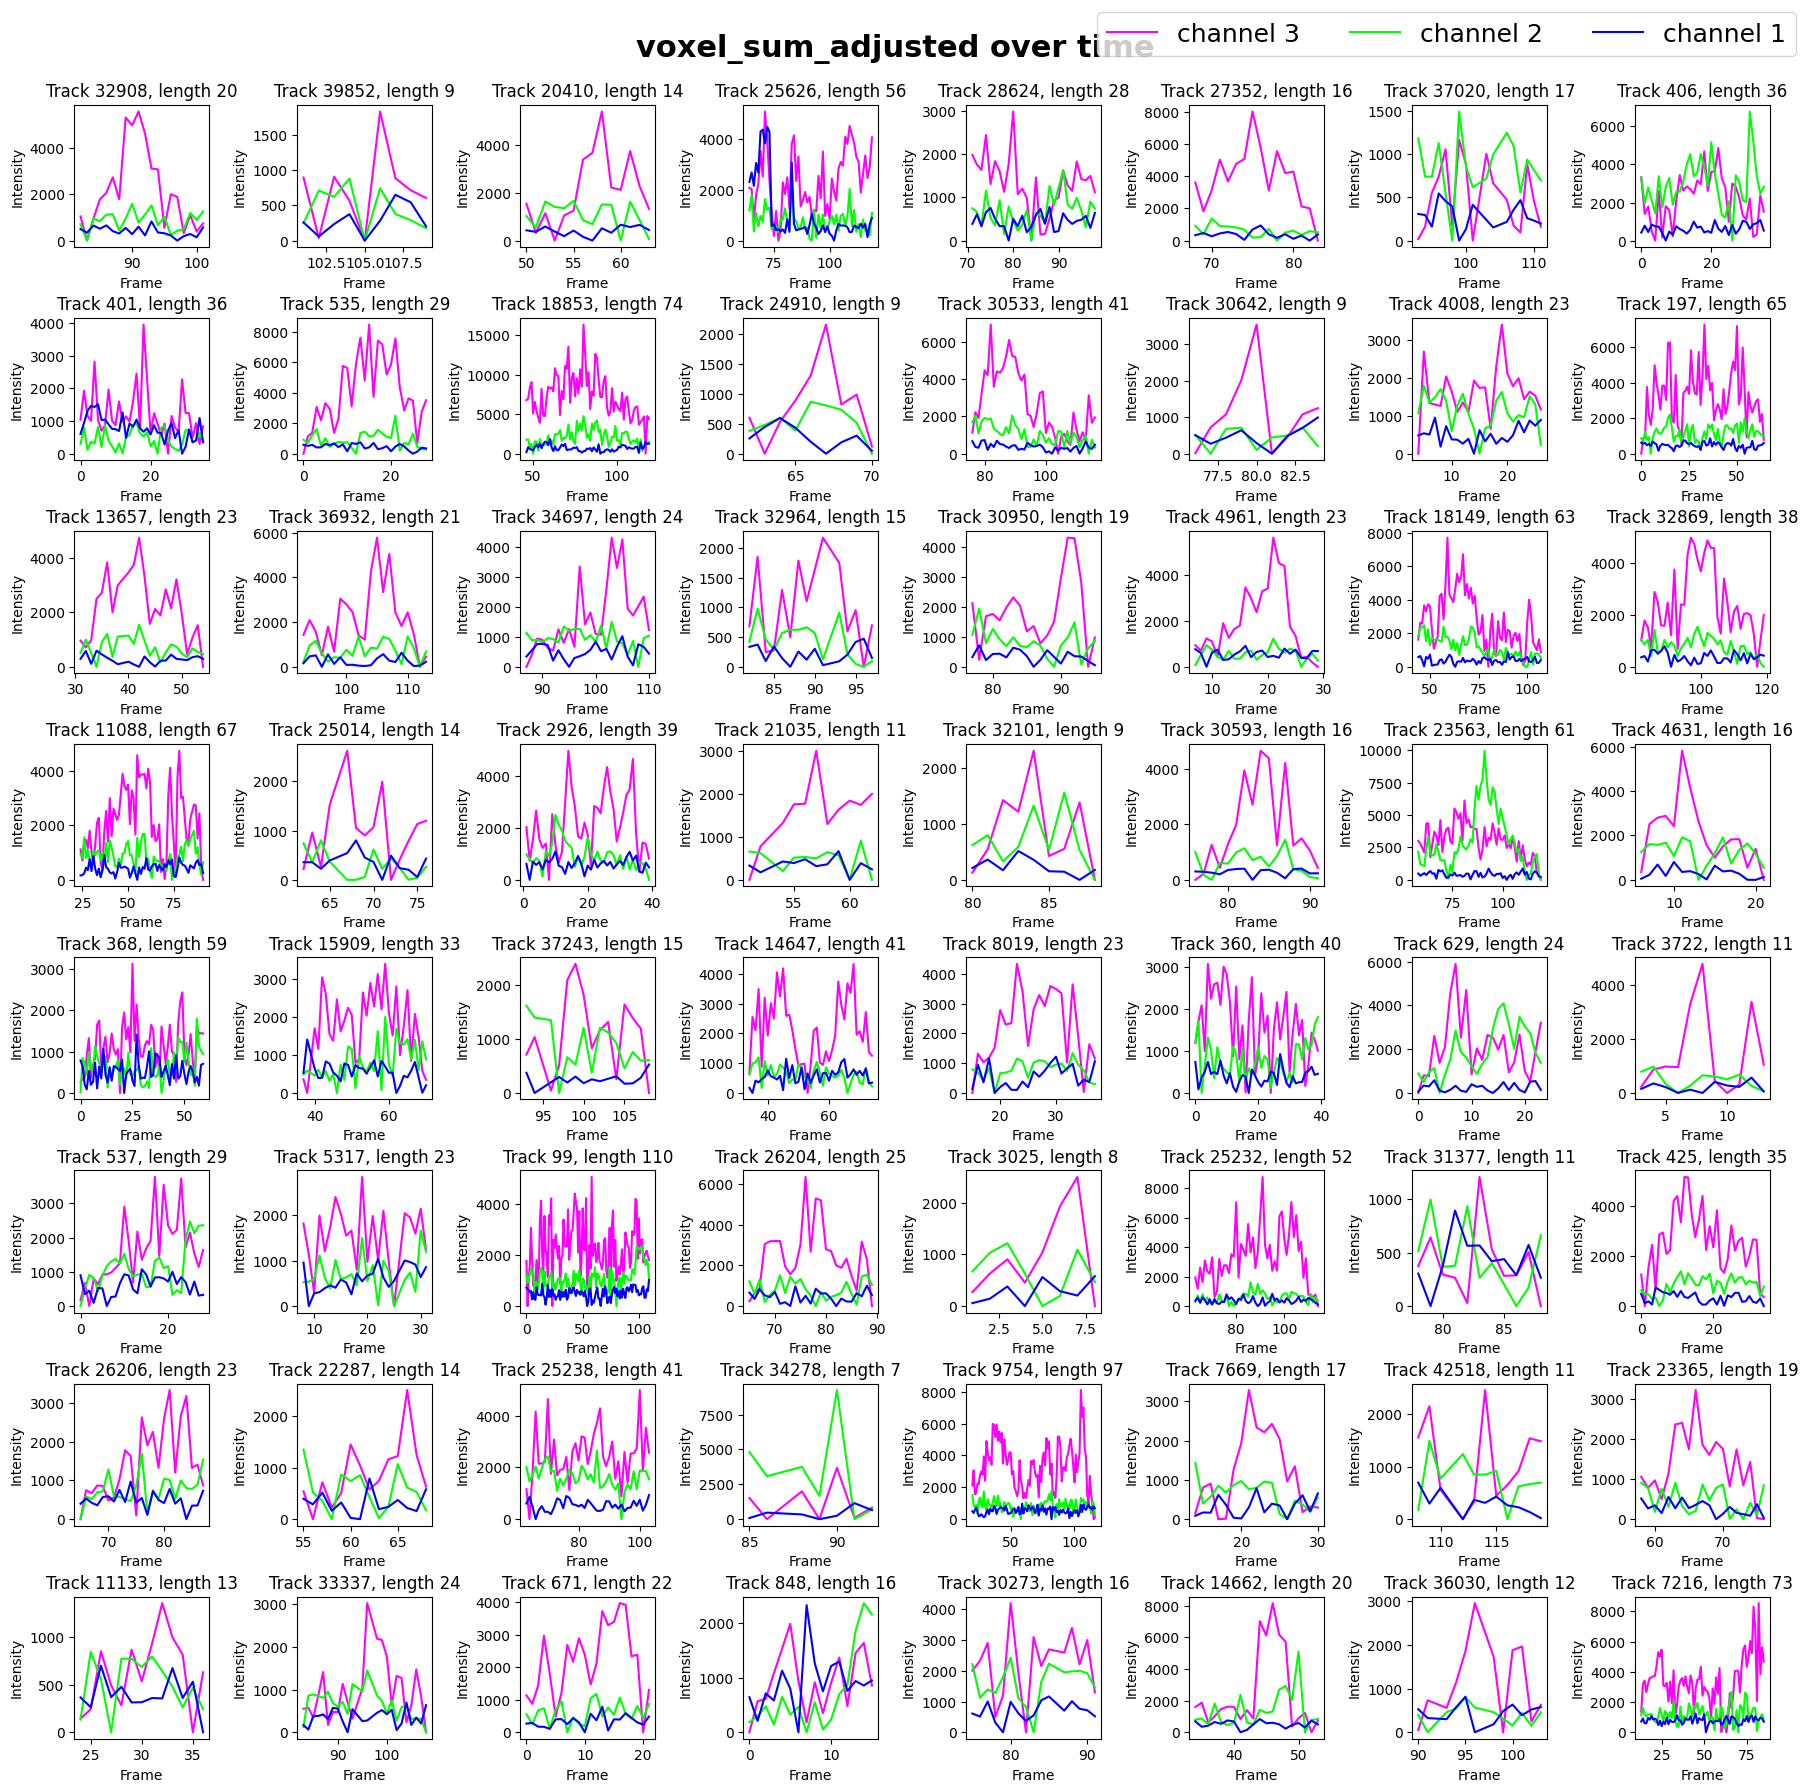

In [30]:
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
value_to_plot = 'voxel_sum_adjusted'

# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = valid_c3_tracks, desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 64)

# plotting 3 channes
intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

# plotting 2 channels
# intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
# intensity_to_plot = [f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
# frame_col_name = 'frame', channels_to_plot = 2, legend_values = [channel2_name, channel1_name],
# line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

### Filtering for Channel 2 
dnm2_positive_tracks will serve as the baseline for dynamin positive tracks

In [31]:
# Channel 2-positive tracks

# dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
#                                           intensity_peak_frame = 'c2_peak')

# dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
#                                           intensity_peak_frame = 'c2_voxel_sum_adjusted_peak')

### Filter tracks based on channel 2 peak if occurs within 3 frames of starting of a track 

# dnm2_positive_tracks = drop_early_peak_tracks(df = dnm2_positive_tracks, intensity_peak_frame = 'c2_peak_frame', 
#                                       cutoff = peak_cutoff)

dnm2_positive_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c2_voxel_sum_adjusted_peak_frame', 
                                      cutoff = peak_cutoff)

### Filter tracks based on channel 2 peaks occuring in the last frame 

# dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'c2_peak_frame')

dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'c2_voxel_sum_adjusted_peak_frame')
dnm2_positive_tracks.shape

(4250, 30)

### Identifying Channel 1 positive tracks 

In [32]:
### Identifying Actin Positive Tracks 
# actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
#                                           intensity_peak_frame = 'c1_peak' )

# actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
#                                           intensity_peak_frame = 'c1_voxel_sum_adjusted_peak' )

### Filter tracks based on channel 1 peaks if occurs within the first 3 frames 

# actin_positive_tracks = drop_early_peak_tracks(df = actin_positive_tracks, intensity_peak_frame = 'c1_peak_frame', 
#                                       cutoff = peak_cutoff)

actin_positive_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c1_voxel_sum_adjusted_peak_frame', 
                                      cutoff = peak_cutoff)

# actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'c1_peak_frame')

actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'c1_voxel_sum_adjusted_peak_frame')

Combining actin and dynamin positive tracks with valid clathrin positive tracks 

In [33]:
final_tracks = valid_c3_tracks.copy(deep = True)
final_tracks['channel2_positive'] = False 
final_tracks['channel1_positive'] = False 

In [34]:
# ***Setting actin positive tracks to True***

# Get the track IDs from actin_positive_tracks
actin_positive_track_ids = actin_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(actin_positive_track_ids), 'channel1_positive'] = True

actin_rows_count = final_tracks[final_tracks['channel1_positive'] == True].shape[0]
print(f'number of {channel1_name} positive tracks are: {actin_rows_count}')

# ***Setting dynamin positive tracks to True***

# Get the track IDs from actin_positive_tracks
dnm2_positive_track_ids = dnm2_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(dnm2_positive_track_ids), 'channel2_positive'] = True

dnm2_rows_count = final_tracks[final_tracks['channel2_positive'] == True].shape[0]
print(f'number of {channel2_name} positive tracks are: {dnm2_rows_count}')


actin_dnm2_rows_count = final_tracks[(final_tracks['channel2_positive'] == True) & 
                                     (final_tracks['channel1_positive'] == True)].shape[0]
print(f"number of {channel1_name} and {channel2_name} positive tracks are: {actin_dnm2_rows_count}")

number of channel 1 positive tracks are: 4057
number of channel 2 positive tracks are: 4250
number of channel 1 and channel 2 positive tracks are: 3236


### Estimating Apical/Basal/Lateral boundaries of cell
Based on the slices with the most intensity in channel 1

In [35]:
import importlib
import filters
importlib.reload(filters)

<module 'filters' from 'D:\\LLSM-CME-ANALYSIS\\Final\\src\\filters.py'>

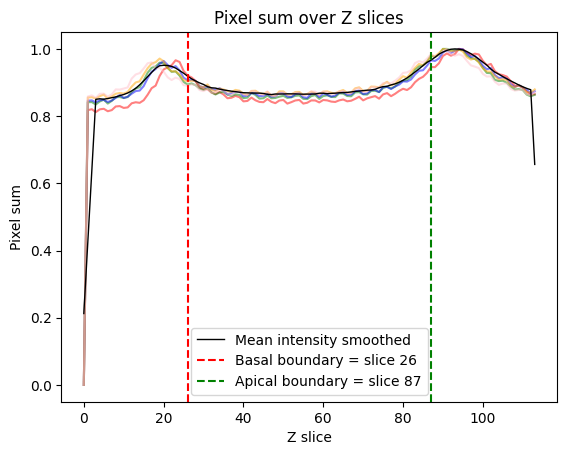

In [36]:
#channel is hard coded in the function right now. Need to allow it to be passed as a parameter by the user 
if membrane_regions_exist == True:      
    boundaries = plot_z_sum_bd(z2)
# print(boundaries)

This Z axis plot shows where the max intensities are, which roughly correspond to the basal and apical regions of the cell.

The lines are the auto-detected boundaries between basal, lateral, and apical.  

If needed, you can scan through the z series in Napari below to adjust the position of these boundaries.

In [37]:
# If ychange the values of the boundaries to the ones you want to use

basal_lateral_boundary_slice_manual = []
lateral_apical_boundary_slice_manual = []

if membrane_regions_exist == True and basal_lateral_boundary_slice_manual:
    boundaries = [basal_lateral_boundary_slice_manual, lateral_apical_boundary_slice_manual]
    print('Manual basal-lateral boundary slice is:', basal_lateral_boundary_slice_manual)   
    print('Manual lateral-apical boundary slice is:', lateral_apical_boundary_slice_manual)

elif membrane_regions_exist == True:
    print('Basal-lateral boundary slice is:', boundaries[0])   
    print('Lateral-apical boundary slice is:', boundaries[1]) 

else:
    print('Analyzing whole cell without membrane regions')   



Basal-lateral boundary slice is: 26
Lateral-apical boundary slice is: 87


In [38]:
# Allocate membrane regions based on the boundaries defined above
if membrane_regions_exist == True: 
    # range is inclusive of the start and exclusive of the end
    allocate_membrane_regions(df = final_tracks, basal_range = [0,26] , lateral_range = [26,87], apical_range = [87,119])

else: 
    final_tracks['membrane_region'] = 'Basal'

In [92]:
# # Subset final tracks such that 25 is less than mean_z less than 30
# final_tracks[(final_tracks['mean_z'] > 25) & (final_tracks['mean_z'] < 30)][['mean_z', 'membrane_region']]
final_tracks.head()

,mu_x,mu_y,mu_z,trackability,track_id,track_length,track_start,track_end,c3_peak,c2_peak,...,c1_voxel_sum_adjusted_peak,c3_voxel_sum_adjusted_peak_frame,c2_voxel_sum_adjusted_peak_frame,c1_voxel_sum_adjusted_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region
0,26 40.0 5486 40.0 5497 40.0 1...,26 70.0 5486 70.0 5497 70.0 1...,26 10.0 5486 10.0 5497 9.0 1...,0,120,0,119,252.228571,252.228571,136.194286,...,1672.157895,103,103,119,6.0,2.0,2.0,True,False,Basal
1,2539 46.0 5485 45.0 5498 46.0 1...,2539 253.0 5485 252.0 5498 253....,2539 9.0 5485 11.0 5498 10.0 1...,1,120,0,119,232.074286,232.074286,152.822857,...,1335.131579,71,71,59,6.0,2.0,2.0,True,True,Basal
2,94 64.0 3184 65.0 7953 64.0 9...,94 200.0 3184 200.0 7953 199....,94 12.0 3184 10.0 7953 11.0 9...,2,120,0,119,187.485714,187.485714,170.057143,...,3704.815789,10,10,53,7.0,3.0,3.0,True,True,Basal
3,207 98.0 4269 98.0 6845 98.0 9...,207 708.0 4269 708.0 6845 708....,207 11.0 4269 10.0 6845 11.0 9...,3,120,0,119,267.571429,267.571429,148.108571,...,1673.815789,105,105,107,6.0,2.0,2.0,True,True,Basal
4,335 105.0 4940 104.0 6117 105....,335 797.0 4940 797.0 6117 797....,335 11.0 4940 11.0 6117 11.0 1...,4,120,0,119,316.194286,316.194286,147.971429,...,1629.078947,117,117,114,6.0,2.0,3.0,True,True,Basal


Save tracks

In [ ]:
final_tracks.to_pickle(output_directory_full)

: 

# Visualize tracks in Napari to assess track filtering quality

In [40]:
# Report number of frames and a random color per track

import random

# Calculate the number of unique frames for each track and create a mapping from track_id to number_of_frames
frame_counts = track_df.groupby('track_id')['frame'].nunique().to_dict()

# Map the frame counts to the original dataframe, creating a new column
track_df['number_of_frames'] = track_df['track_id'].map(frame_counts)

# Assuming 'track_df' is your DataFrame
track_ids = track_df['track_id'].unique().tolist()

# Generate a list of random colors
colors = [random.randint(0, 255) for _ in range(len(track_ids))]

# Create a dictionary that maps each track id to a random color
color_dict = dict(zip(track_ids, colors))

# Now you can use this dictionary to assign colors to the tracks
track_df['color'] = track_df['track_id'].map(color_dict)

# Sort track_df by frame and track_id
track_df = track_df.sort_values(by=['frame', 'track_id']).reset_index(drop=True)

track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,sigma_z,sigma_y,sigma_x,c1_peak_mean,...,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg,number_of_frames,color
0,0,49.0,1314.0,18.0,730.0,0,3,2,2,278.377143,...,730,68522,21323.973684,48,1313,17,175,441,120,137
1,0,121.0,1289.0,31.0,435.0,1,3,2,2,308.800000,...,435,35464,8504.131579,120,1288,30,175,441,120,40
2,0,71.0,876.0,35.0,321.0,2,3,2,2,312.371429,...,321,27602,5754.702703,70,875,32,175,434,120,188
3,0,77.0,86.0,31.0,359.0,3,3,2,2,172.908571,...,359,35005,8637.894737,77,85,29,175,441,120,173
4,0,161.0,904.0,40.0,1065.0,4,3,2,2,270.320000,...,1065,88143,38794.315789,161,904,38,175,441,120,60


In [26]:
# # Create a napari viewer
# viewer = napari.Viewer()

# #access channel 3 only from zarr array 
# dask_array = da.from_zarr(z2)

# #the axis arrangement is (t,c,z,y,x)
# #for the sake of improved performance only 1 channel could be imported here (if images get super large and performance issues occur)
# all_channels = dask_array[:,:,:,:,:]

# # # Calculate the 1st and 99th percentiles for the 10th time point
# # lower_limit_1, upper_limit_1 = da.percentile(all_channels[10,0,:,:,:].ravel(), [5, 95]).compute()
# # lower_limit_2, upper_limit_2 = da.percentile(all_channels[10,1,:,:,:].ravel(), [5, 95]).compute()
# # lower_limit_3, upper_limit_3 = da.percentile(all_channels[10,2,:,:,:].ravel(), [5, 95]).compute()


# # # Set the contrast limits

# # # Add each channel as a separate image layer with its own contrast limits
# # layer_raw_1 = viewer.add_image(all_channels[0], contrast_limits=[lower_limit_1, upper_limit_1], name='channel 1', colormap='yellow')
# # layer_raw_2 = viewer.add_image(all_channels[1], contrast_limits=[lower_limit_2, upper_limit_2], name='channel 2', colormap = 'cyan')
# # layer_raw_3 = viewer.add_image(all_channels[2], contrast_limits=[lower_limit_3, upper_limit_3], name='channel 3', colormap = 'magenta')

# # Add the 4D stack to the viewer
# layer_raw = viewer.add_image(all_channels, channel_axis = 1, name = ['channel 1', 'channel 2', 'channel 3'])
# #other useful parameters 
# #color_map = list
# #contrast_limits = list of list 

# track_properties = {'number_of_frames': track_df['number_of_frames'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}
# # track_properties = {'number_of_frames': track_df['track_length'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}


# # viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks')

# tracks_layer = viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks', properties=track_properties, color_by='track_id_rand', tail_length = 15, tail_width = 2, colormap = 'hsv')

# # Add Bounding Box
# layer_raw[0].bounding_box.visible = True
# layer_raw[1].bounding_box.visible = True
# layer_raw[2].bounding_box.visible = True


In [27]:
# #Displaying Dynamin Positive tracks only (Tracks where actin is not present)
# dnm2_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == False)]
# dnm2_tracks_list = dnm2_positive_tracks_df['track_id'].values
# track_1 = track_df[track_df['track_id'].isin(dnm2_tracks_list)]
# viewer.add_tracks(track_1[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel2+ tracks')

In [28]:
# #Displaying Actin Positive tracks only (Tracks where Dynamin is not present)
# actin_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == False) & (final_tracks['channel1_positive'] == True)]
# actin_tracks_list = actin_positive_tracks_df['track_id'].values
# track_2 = track_df[track_df['track_id'].isin(actin_tracks_list)]
# viewer.add_tracks(track_2[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel1+ tracks')

In [29]:
# #Displaying all 3 channels positive tracks 
# all_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == True)]
# all_positive_tracks_list = all_positive_tracks_df['track_id'].values
# track_3 = track_df[track_df['track_id'].isin(all_positive_tracks_list)]
# viewer.add_tracks(track_3[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all+ tracks')

In [30]:
# #Displaying basal tracks 
# if membrane_regions_exist == True: 
#     basal_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Basal']
#     basal_tracks_list = basal_tracks_df['track_id'].values
#     track_4 = track_df[track_df['track_id'].isin(basal_tracks_list)]
#     viewer.add_tracks(track_4[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'basal tracks')

In [31]:
# #Displaying lateral tracks 
# if membrane_regions_exist == True:
#     lateral_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Lateral']
#     lateral_tracks_list = lateral_tracks_df['track_id'].values
#     track_5 = track_df[track_df['track_id'].isin(lateral_tracks_list)]
#     viewer.add_tracks(track_5[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Lateral tracks')

In [32]:
# #Displaying apical tracks 
# if membrane_regions_exist == True:
#     apical_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Apical']
#     apical_tracks_list = apical_tracks_df['track_id'].values
#     track_6 = track_df[track_df['track_id'].isin(apical_tracks_list)]
#     viewer.add_tracks(track_6[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Apical tracks')

### final_tracks dataframe stores tracks which are at least positive in the channel you tracked.

## Once you have performed this step and have filtered tracks  you can now use the dashboard to test performance of the pipeline and access visualisations. 

# Go to multipage_dashboard and run app.py 